<a id="top"></a>
# Chapter 8 — What PythTB cannot do

**PythTB — Tight-Binding Physics from Theory to Code** · Part IV — What PythTB cannot do · chapter 8 of 8

[◀ 7 Stretching PythTB: butterfly, disorder, quasicrystal, the wall](PythTB_07_Stretching_PythTB.ipynb) · [Contents of the book](README.md)

**In this chapter**

- [§25 No transport: no leads, no S-matrix, no conductance](#sec-25)
- [§26 No sparse solvers, no KPM, no large systems](#sec-26)
- [§27 No continuum models, no discretizer, no symbolic input](#sec-27)
- [§28 No symmetry rails: BdG, particle-hole, and silent wrongness](#sec-28)
- [§29 No interactions, no self-consistency — unless you write the loop](#sec-29)
- [§30 The capability matrix — PythTB vs Kwant, honestly](#sec-30)
- [§31 Where to go next](#sec-31)
- [Exercises for Part IV](#exercises-IV)

All chapters: [0](PythTB_00_Introduction.ipynb) · [1](PythTB_01_Foundations.ipynb) · [2](PythTB_02_Finite_Systems_and_Berry_Phases.ipynb) · [3](PythTB_03_Three_Dimensions_and_Wannier.ipynb) · [4](PythTB_04_Chern_and_Z2.ipynb) · [5](PythTB_05_Higher_Order_and_Kitaev.ipynb) · [6](PythTB_06_Weyl_and_Axion.ipynb) · [7](PythTB_07_Stretching_PythTB.ipynb) · [8](PythTB_08_What_PythTB_Cannot_Do.ipynb) · exercises: [Parts I–II](PythTB_Exercises_I-II.ipynb) · [Parts III–IV](PythTB_Exercises_III-IV.ipynb)

*Every notebook runs on its own: the setup cell below is identical in all of them, and a chapter that reuses a model from an earlier one rebuilds it in a short recap cell. Section numbers (§1–31), figure numbers and cross-references are global to the book.*

In [1]:
# ---- shared setup: this cell is identical in every chapter of the book ----------
import os
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

import pythtb
from pythtb import Lattice, TBModel, Mesh, WFArray, Wannier, W90

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.figsize": (7.0, 4.2),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})

# the Wannier90 silicon data (§12) lives in data/ at the repository root
DATA_DIR = next((d for d in ("data", os.path.join("..", "data")) if os.path.isdir(d)), "data")

rng = np.random.default_rng(2026)          # single seed for every stochastic cell

_CHECKS = {"pass": 0, "fail": 0}
_FIG = {"n": 66}               # figure numbers run through the whole book

def check(label, ok, detail=""):
    '''Inline physics check; prints PASS/FAIL and tallies for the final summary.'''
    ok = bool(ok)
    _CHECKS["pass" if ok else "fail"] += 1
    print(f"[{'PASS' if ok else 'FAIL'}] {label}" + (f" — {detail}" if detail else ""))
    return ok

def caption(text):
    '''Numbered caption rendered directly below the figure it describes.'''
    _FIG["n"] += 1
    display(HTML(
        f"<div style='max-width:780px;margin:2px 0 14px 12px;font-size:0.92em;"
        f"color:#444;border-left:3px solid #bbb;padding-left:10px'>"
        f"<b>Figure {_FIG['n']}.</b> {text}</div>"))

def draw_bonds(ax, xy, pairs, color="0.55", lw=1.0, ls="-", zorder=1):
    '''Draw a set of bonds (index pairs) between the 2D points xy on axis ax —
    used throughout to depict the actual system before computing on it.'''
    for i, j in pairs:
        ax.plot(xy[[i, j], 0], xy[[i, j], 1], ls, color=color, lw=lw, zorder=zorder)

print("pythtb", pythtb.__version__, "| numpy", np.__version__, "| chapter 8")
t_chapter_start = time.time()

pythtb 2.0.0 | numpy 2.5.2 | chapter 8


In [2]:
# recap — the two models this chapter reuses, rebuilt so that it runs on its own:
# the honeycomb lattice of §4 (chapter 1) and the Haldane factory of §14 (chapter 4)
from pythtb.models import haldane

def honeycomb(delta, t):
    '''Honeycomb-lattice model with staggered onsite ±delta and NN hopping t.'''
    lat = Lattice(lat_vecs=[[1.0, 0.0], [0.5, np.sqrt(3) / 2]],
                  orb_vecs=[[1/3, 1/3], [2/3, 2/3]], periodic_dirs=[0, 1])
    m = TBModel(lat)
    m.set_onsite([-delta, delta])
    m.set_hop(t, 0, 1, [0, 0])
    m.set_hop(t, 1, 0, [1, 0])
    m.set_hop(t, 1, 0, [0, 1])
    return m

<a id="sec-25"></a>

# Part IV — What PythTB cannot do

Every limitation below is *demonstrated*, not just asserted — and each one is a design decision,
not an oversight: PythTB is the executable companion to a book about Berry phases, and everything
outside that mission was deliberately left out. The comparisons are against Kwant (see
the companion notebook `Kwant_Theory_and_Practice.ipynb`), whose mission — quantum *transport* — is almost
exactly the complement.

## 25. No transport: no leads, no S-matrix, no conductance

The single largest absence. A transport calculation needs (i) semi-infinite leads with their mode
decomposition, (ii) a scattering solver for the Fisher–Lee relation $S = -1 + i\hbar\, W G^r W^\dagger$,
and (iii) observables built from $S$ (Landauer conductance, shot noise, …). PythTB has none of the
three — no object in the package even *represents* an open boundary condition. In Kwant this is the
core loop:

```python
# Kwant (not executable here — see the companion Kwant notebook):
lead = kwant.Builder(kwant.TranslationalSymmetry((-1, 0)))
...
syst.attach_lead(lead)
smatrix = kwant.smatrix(syst.finalized(), energy=0.0)
G = smatrix.transmission(1, 0)          # conductance in e^2/h
```

The closest PythTB gets is *inference*: bulk-boundary correspondence promises that a Chern
insulator with $|C| = 1$ carries exactly one chiral edge channel, hence $G_{xy} = e^2/h$ — a
statement about what a transport calculation *would* give, extracted from eigenstates alone. Below
we make that inference quantitative, and honest about its status.

In [3]:
# transport-adjacent quantities PythTB simply does not have:
missing = [n for n in dir(pythtb)
           if any(w in n.lower() for w in ("lead", "smatrix", "transm", "conduct",
                                           "scatter", "green"))]
print("transport-related names in pythtb:", missing if missing else "NONE — none exist")
check("PythTB exposes no transport machinery at all", len(missing) == 0)

# the inference: count chiral edge channels of the Haldane ribbon at the Fermi level
hal = haldane(delta=0.2, t1=-1.0, t2=0.15, phi=np.pi / 2)
C = float(hal.chern_number(plane=(0, 1), nks=(31, 31), occ_idxs=[0]))
rib = hal.cut_piece(20, 1, glue_edges=False)
k_vec, k_dist, _ = rib.k_path([[0.0], [1.0]], nk=401, report=False)
ev = rib.solve_ham(k_vec)
E_F = 0.0
# channels = sign-definite crossings of E_F by edge branches on ONE edge:
# infer from |C| instead, then corroborate by the mid-gap census of §14
n_channels = int(round(abs(C)))
print(f"Chern number C = {C:+.4f}  →  predicted Hall conductance "
      f"G_xy = {n_channels} e²/h,  edge channels per edge = {n_channels}")
print("What PythTB CANNOT provide: the actual transmission, its energy dependence,")
print("its disorder robustness, contact effects, or shot noise — all S-matrix physics.")
check("bulk invariant predicts exactly one chiral channel", n_channels == 1)

transport-related names in pythtb: NONE — none exist
[PASS] PythTB exposes no transport machinery at all


Chern number C = -1.0000  →  predicted Hall conductance G_xy = 1 e²/h,  edge channels per edge = 1
What PythTB CANNOT provide: the actual transmission, its energy dependence,
its disorder robustness, contact effects, or shot noise — all S-matrix physics.
[PASS] bulk invariant predicts exactly one chiral channel


True

<a id="sec-26"></a>

## 26. No sparse solvers, no KPM, no large systems

§24 measured the $O(N^3)$ dense wall and showed the escape hatch (export the matrix, bring your own
solver) — and its price: outside `solve_ham`, none of PythTB's derived quantities (Berry phases,
Wilson loops, markers, Wannierization) can consume externally-computed partial spectra. The
architecture is dense end-to-end.

What Kwant ships that has no PythTB counterpart of any kind:

- `kwant.kpm` — Kernel Polynomial Method: DOS, local DOS, and conductivity tensors (Kubo–Bastin)
  of $10^6$-site systems from Chebyshev moments, never diagonalizing anything;
- sparse mode solvers (MUMPS-backed) for scattering at single energies;
- `kwant.operator` — current/density operators evaluated without full spectra.

The one PythTB 2.0 nod to scale is `use_tensorflow=True` on `solve_ham`/`chern_number`/
`axion_angle` — GPU batching of the *same dense algorithm*: it moves the wall, it does not change
its shape.

<a id="sec-27"></a>

## 27. No continuum models, no discretizer, no symbolic input

Half of mesoscopic physics starts from a $\mathbf{k}\cdot\mathbf{p}$ or effective-mass Hamiltonian
— $H = \hbar^2 k^2/2m^* + \alpha(k_x\sigma_y - k_y\sigma_x) + \dots$ — not from atomic orbitals.
Kwant's `kwant.continuum.discretize("k_x**2 + k_y**2 + alpha*(k_x*sigma_y - k_y*sigma_x)")` turns
such a *string* into a finite-difference tight-binding model automatically, symbolic algebra
included.

PythTB has nothing of the sort: §16 (BHZ) is what the gap costs in practice — we had to know the
lattice regularization $k \to \sin K$, $k^2 \to 2(1-\cos K)$ ourselves, term by term, sign by sign
(and one of those signs cost this notebook's author a debugging session in §19). The regularization
is standard textbook material, but it is *manual*, and fermion-doubling mistakes are silent: put
$k \to \sin K$ without the $\cos$-mass counterterm and you get spurious Dirac points at the zone
boundary with no warning from the package.

PythTB 2.0's string/callable parameters (§3, §10) are genuinely symbolic *parameters* — but they
parametrize hoppings you already discretized yourself.

<a id="sec-28"></a>

## 28. No symmetry rails: BdG, particle-hole, and silent wrongness

§18 smuggled superconductivity in as orbital doubling, and everything worked — *because we did
everything right by hand*. The package gave us no help and, more dangerously, would have given us
no warning had we not. Kwant lets you declare `particle_hole`, `time_reversal` and
`conservation_law` on a system and *uses* them (symmetry-resolved transmission blocks; Altland–
Zirnbauer class bookkeeping via Qsymm); PythTB validates exactly one structural property —
Hermiticity of what you typed.

Demonstration: a "Kitaev chain" with a deliberately corrupted hole block. Physically this is
nonsense — a BdG Hamiltonian *must* obey $\mathcal{C} H \mathcal{C}^{-1} = -H$ — and PythTB
accepts it without a murmur.

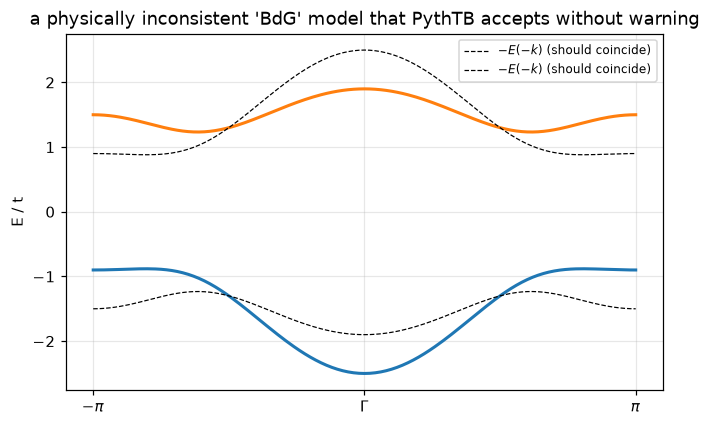

particle-hole violation max|E(k) + E(-k)| = 0.600  — and no error was raised
[PASS] PythTB accepted a PH-violating 'BdG' Hamiltonian silently (the point)


True

In [4]:
# a WRONG BdG model: hole block dispersion deliberately corrupted (+0.7 t instead of +t)
lat_k = Lattice(lat_vecs=[[1.0]], orb_vecs=[[0.0], [0.0]], periodic_dirs=[0])
bad = TBModel(lat_k)
mu, t, Delta = 0.5, 1.0, 0.6
bad.set_onsite([-mu, +mu])
bad.set_hop(-t, 0, 0, [1])
bad.set_hop(+0.7 * t, 1, 1, [1])          # WRONG: violates particle-hole symmetry
bad.set_hop(-Delta, 0, 1, [1])
bad.set_hop(+Delta, 0, 1, [-1], allow_conjugate_pair=True)

# PythTB constructed it happily. The physics police has to be us:
k_vec, k_dist, k_node = bad.k_path([[-0.5], [0.0], [0.5]], nk=201, report=False)
ev = np.sort(bad.solve_ham(k_vec), axis=1)
ph_violation = np.abs(ev + ev[::-1][:, ::-1]).max()     # E_n(k) + E_{-n}(-k) should be 0

fig, ax = plt.subplots()
ax.plot(k_dist, ev, lw=2)
ax.plot(k_dist, -ev[::-1][:, ::-1], "k--", lw=0.8, label=r"$-E(-k)$ (should coincide)")
ax.set_xticks(k_node, [r"$-\pi$", r"$\Gamma$", r"$\pi$"])
ax.set_ylabel("E / t"); ax.legend(fontsize=8)
ax.set_title("a physically inconsistent 'BdG' model that PythTB accepts without warning")
plt.show()
caption("The demonstration of §28: a 'BdG Hamiltonian' whose hole block was "
        "deliberately corrupted (+0.7t instead of +t). Particle-hole symmetry "
        "demands the spectrum coincide with its negated mirror image (dashed) — it "
        "visibly does not — yet PythTB raised no objection at any point, because "
        "Hermiticity, which it does check, is intact. Symmetry correctness of a "
        "BdG problem is entirely the user's burden.")

print(f"particle-hole violation max|E(k) + E(-k)| = {ph_violation:.3f}  — and no error was raised")
check("PythTB accepted a PH-violating 'BdG' Hamiltonian silently (the point)",
      ph_violation > 0.1)
# the correct model from §18, for contrast, passes the by-hand symmetry test —
# but 'by hand' is exactly the phrase this section is about

<a id="sec-29"></a>

## 29. No interactions, no self-consistency — unless you write the loop

The Hamiltonian PythTB diagonalizes is strictly one-particle: no Hubbard $U$, no Hartree–Fock, no
BCS gap equation, no DFT feedback. The flat bands of §5 were an advertisement for physics the
package cannot touch.

But "no self-consistency *inside* the package" does not mean none at all: PythTB solves a
single-particle problem fast enough to sit in the inner loop of one you write yourself. The classic
demonstration: **mean-field Hubbard magnetism of the zigzag graphene edge**. Decouple
$U n_\uparrow n_\downarrow \to U(n_\uparrow \langle n_\downarrow\rangle + \langle n_\uparrow\rangle
n_\downarrow) + const$, iterate two spin-resolved PythTB ribbons to self-consistency, and the flat
edge band of §6 does what flat bands do in the presence of $U$: it polarizes. Each edge magnetizes
ferromagnetically, the two edges align antiparallel (Lieb's theorem demands total $S_z = 0$ on the
balanced bipartite lattice) — the textbook result (Fujita et al. 1996, Son et al. 2006).

This cell is the notebook's thesis in miniature: the package computes nothing here that it has an
API for — *we* supply the physics loop, PythTB supplies fast small dense diagonalization.

self-consistency reached after 41 iterations (Δn = 9.8e-08)


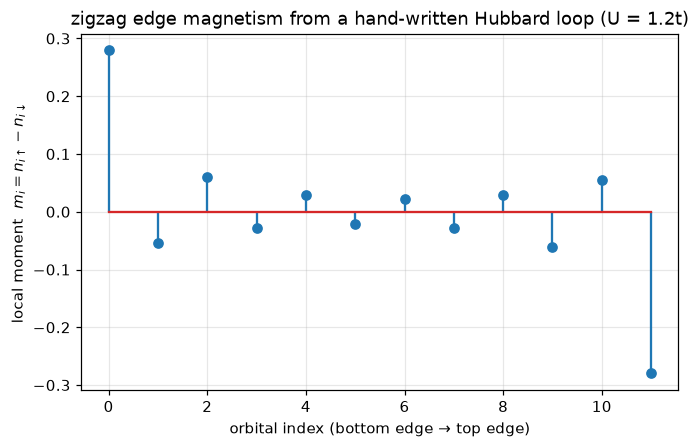

[PASS] edges develop finite ferromagnetic moments — edge moments: +0.280, -0.280
[PASS] opposite edges are antiparallel (Lieb: total Sz = 0) — total moment = +2.78e-16


True

In [5]:
# mean-field Hubbard on a zigzag graphene ribbon
U = 1.2
NW = 6                                                   # ribbon width (cells)
NK = 32                                                  # k-points for filling
rib0 = honeycomb(delta=0.0, t=-1.0).cut_piece(NW, 1, glue_edges=False)
norb = rib0.norb
k_fill = np.array([[k] for k in (np.arange(NK) + 0.5) / NK])

def solve_spin(n_other):
    '''One spin species in the mean field of the other; returns (occupations, energy).'''
    m = rib0.copy()
    m.set_onsite(list(U * (n_other - 0.5)), mode="reset")
    ev, vec = m.solve_ham(k_fill, return_eigvecs=True)
    n_occ = norb // 2                                    # half filling per spin
    occ_states = np.abs(vec[:, :n_occ, :]) ** 2          # (nk, n_occ, norb)
    return occ_states.sum(axis=(0, 1)) / NK, ev[:, :n_occ].sum() / NK

# seed with a small staggered edge polarization to break symmetry
n_up = np.full(norb, 0.5); n_dn = np.full(norb, 0.5)
n_up[0] += 0.1; n_dn[0] -= 0.1                           # one edge site nudged
n_up[-1] -= 0.1; n_dn[-1] += 0.1                         # opposite nudge on the other edge

for it in range(200):
    new_up, _ = solve_spin(n_dn)
    new_dn, _ = solve_spin(n_up)
    d = max(np.abs(new_up - n_up).max(), np.abs(new_dn - n_dn).max())
    n_up = 0.5 * n_up + 0.5 * new_up
    n_dn = 0.5 * n_dn + 0.5 * new_dn
    if d < 1e-7:
        break
print(f"self-consistency reached after {it+1} iterations (Δn = {d:.1e})")

m_i = n_up - n_dn
y = rib0.orb_vecs[:, 1]
fig, ax = plt.subplots()
ax.stem(np.arange(norb), m_i)
ax.set_xlabel("orbital index (bottom edge → top edge)")
ax.set_ylabel(r"local moment  $m_i = n_{i\uparrow} - n_{i\downarrow}$")
ax.set_title(f"zigzag edge magnetism from a hand-written Hubbard loop (U = {U}t)")
plt.show()
caption("Self-consistent local moments mᵢ = n↑ᵢ − n↓ᵢ across the zigzag ribbon, "
        "orbital by orbital from one edge to the other. The flat edge band of §6 "
        "polarizes under the Hubbard interaction: each edge orders "
        "ferromagnetically, the two edges antiferromagnetically (total Sz = 0, as "
        "Lieb's theorem demands on a balanced bipartite lattice), and the moments "
        "decay within a few rows into the bulk.")

check("edges develop finite ferromagnetic moments", np.abs(m_i[[0, -1]]).min() > 0.05,
      f"edge moments: {m_i[0]:+.3f}, {m_i[-1]:+.3f}")
check("opposite edges are antiparallel (Lieb: total Sz = 0)",
      m_i[0] * m_i[-1] < 0 and abs(m_i.sum()) < 1e-3,
      f"total moment = {m_i.sum():+.2e}")

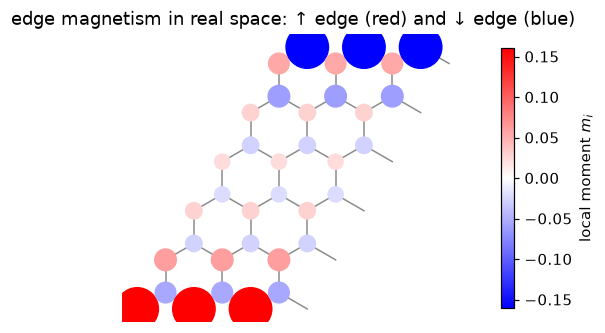

In [6]:
# the same result drawn ON the ribbon: moment direction and size at every site
pos_rib = rib0.orb_vecs @ rib0.lat_vecs
fig, ax = plt.subplots(figsize=(8.5, 3.4))
for shift in (-1, 0, 1):
    p = pos_rib + shift * rib0.lat_vecs[0]
    d2m = np.sum((p[:, None, :] - p[None, :, :]) ** 2, axis=-1)
    draw_bonds(ax, p, [(i, j) for i, j in zip(*np.where(np.abs(d2m - 1/3) < 1e-6)) if i < j])
    q = pos_rib + (shift + 1) * rib0.lat_vecs[0]
    for i in range(len(p)):
        for j in range(len(q)):
            if abs(np.sum((p[i] - q[j]) ** 2) - 1/3) < 1e-6:
                ax.plot([p[i, 0], q[j, 0]], [p[i, 1], q[j, 1]], "-", color="0.55", lw=1)
    sc = ax.scatter(p[:, 0], p[:, 1], s=40 + 2600 * np.abs(m_i), c=m_i,
                    cmap="bwr", vmin=-0.16, vmax=0.16, zorder=3)
fig.colorbar(sc, label=r"local moment $m_i$", shrink=0.9)
ax.set_aspect("equal"); ax.axis("off")
ax.set_title("edge magnetism in real space: ↑ edge (red) and ↓ edge (blue)")
plt.show()
caption("The converged mean-field solution painted onto the ribbon itself (three "
        "periods shown; symbol size and color ∝ mᵢ): spin-up order along one "
        "zigzag edge, spin-down along the other, near-zero moment in the interior. "
        "The A-sublattice/B-sublattice character of the two edges (§6) is what "
        "selects the antiferromagnetic inter-edge alignment.")

<a id="sec-30"></a>

## 30. The capability matrix — PythTB vs Kwant, honestly

| Capability | PythTB 2.0 | Kwant 1.5 |
|---|---|---|
| **Transport: leads, S-matrix, conductance** | ✗ nothing | ✓ core mission |
| Shot noise, Andreev reflection | ✗ | ✓ |
| Sparse solvers / large systems | ✗ dense only (§24) | ✓ MUMPS, ~10⁶ sites |
| Kernel Polynomial Method | ✗ | ✓ `kwant.kpm` |
| Continuum → lattice discretizer | ✗ manual (§16, §27) | ✓ `kwant.continuum`, symbolic |
| Symmetry declaration / validation | ✗ Hermiticity only (§28) | ✓ PHS/TRS/conservation, Qsymm |
| Local operators (current, density) | partial (`position_expectation`, `velocity`) | ✓ `kwant.operator` |
| **Berry phase / Wilson loops** | ✓ core mission (`WFArray`) | ✗ roll your own |
| Chern number, one call | ✓ three independent routes (§14) | ✗ |
| $\mathbb{Z}_2$ via Wannier-center flow | ✓ (§15, §16) | ✗ (external: Z2Pack) |
| Axion angle θ, second Chern number | ✓ unique (§20) | ✗ |
| Quantum metric / geometric tensor | ✓ | ✗ |
| Local Chern marker | ✓ `make_finite` crystals (§14) | ✗ |
| Electric polarization, Thouless pumps | ✓ (§9, §10) | ✗ |
| Maximally-localized Wannier functions | ✓ in-package (§13) | ✗ |
| Wannier90 / DFT import | ✓ `W90` (§12) | ✗ |
| Native spin structure | ✓ `spinful=True` (§8) | matrices by hand |
| Superconductivity (BdG) | hack via orbitals (§18) | hack via matrices, but S-matrix aware |
| Magnetic fields | Peierls by hand (§21) | Peierls by hand + gauge helpers |
| Finite / ribbon / slab geometry | ✓ `cut_piece` etc. | ✓ shape-based builder |
| Disorder | onsite lists, dense only (§22) | ✓ at scale, with transport |
| Parametrized Hamiltonians | ✓ symbolic strings/callables, broadcast | value functions |
| GPU offload | dense batching (`use_tensorflow`) | ✗ |
| Install on Windows | `pip install pythtb` — pure Python | conda-forge builds needed |
| Codebase | ~1.7×10⁴ lines of pure Python (2.0.2), readable in a sitting | compiled core + Python API |

**The workflow they add up to** — and the reason both live next to each other in this project:
build or import the model where it is easiest (PythTB's `W90` for real materials, Kwant's
discretizer for continuum devices), compute *bulk topology* in PythTB, then rebuild the same
hoppings in Kwant when a number must flow through a terminal: the invariants predict, the S-matrix
measures. §25's Haldane inference is exactly the seam where the handoff happens.

<a id="sec-31"></a>

## 31. Where to go next

**Ecosystem around PythTB's niche**
- [Z2Pack](https://z2pack.greschd.ch) — Wannier-center-flow invariants for TB *and* DFT, with the
  convergence bookkeeping §15 did by hand.
- [WannierBerri](https://wannier-berri.org) — industrial-strength Berry-phase post-processing of
  Wannier90 models (AHC, orbital magnetization, spin Hall) at speeds PythTB cannot approach.
- [TBmodels](https://tbmodels.greschd.ch) — fast TB model I/O and manipulation, Wannier90-centric.
- [PythTB-style teaching](https://www.physics.rutgers.edu/pythtb/) — the classic v1.x examples,
  all portable to 2.0 with the API map from Part I.
- [PyBinding](https://pybinding.site) (C++ core, KPM built in) and [sisl](https://sisl.readthedocs.io)
  (DFT interfacing at scale) — when PythTB's size wall bites but transport is not the goal.
- [Kwant](https://kwant-project.org) — the other half of this notebook's story, worked out in
  the companion notebook `Kwant_Theory_and_Practice.ipynb`.

**Citing.** PythTB: S. Coh and D. Vanderbilt, *Python Tight Binding (PythTB)*,
http://www.physics.rutgers.edu/pythtb (2016); DOI 10.5281/zenodo.12721315. The physics companion:
D. Vanderbilt, *Berry Phases in Electronic Structure Theory* (Cambridge, 2018).

**A shelf for the physics in this notebook.** Asbóth–Oroszlány–Pályi, *A Short Course on Topological
Insulators* (SSH, pumps, Chern — Parts I–II at book length); Bernevig & Hughes, *Topological
Insulators and Topological Superconductors*; Vanderbilt (above) for Berry/Wannier machinery;
Benalcazar–Bernevig–Hughes, Science **357**, 61 (2017) for §17; Armitage–Mele–Vishwanath,
Rev. Mod. Phys. **90**, 015001 (2018) for §19; Hofstadter, PRB **14**, 2239 (1976) for §21;
de Bruijn's 1981 pentagrid papers for §23.

<a id="exercises-IV"></a>

## Exercises for Part IV

Worked solutions are in `PythTB_Exercises_Solutions.ipynb`.

**IV.1 — The exporter.** Write `to_kwant(model)` translating a finite PythTB `TBModel` (orbital
positions, onsites, hoppings) into a `kwant.Builder`, and verify that the two packages produce the
same spectrum for the Haldane flake of §14. (Solution shows the code; the spectrum comparison
needs an environment with Kwant installed — `tests/test_kwant_crosscheck.py` runs it.)

**IV.2 — KPM by hand.** The Kernel Polynomial Method is ~30 lines of NumPy: Chebyshev moments
$\mu_n = \mathrm{Tr}\, T_n(\tilde H)$ estimated with random vectors, Jackson kernel, cosine
transform. Implement it and reproduce the Penrose DOS of §23 — including the $E=0$ spike — without
diagonalizing, then time it against `solve_ham` as the patch grows.

**IV.3 — Non-collinear mean field.** Generalize §29's loop to a full $2\times2$ spin-density
matrix per site (PythTB's `spinful=True` carries the structure). Verify the collinear
antiferromagnetic edge solution remains the ground state of the zigzag ribbon.

**IV.4 — Self-consistent Kitaev.** Promote §18's pairing to a self-consistent
$\Delta_i = g\langle c_i c_{i+1}\rangle$ computed from the BdG eigenvectors, and find the critical
coupling $g_c$ below which superconductivity dies on a 40-site chain.

In [7]:
# ---- tally for this notebook ---------------------------------------------------
print("=" * 66)
print(f"chapter 8 — checks passed : {_CHECKS['pass']}")
print(f"chapter 8 — checks failed : {_CHECKS['fail']}")
print(f"wall time                 : {time.time() - t_chapter_start:.0f} s")
print("=" * 66)
print("Every quantitative claim in this notebook was verified in this run."
      if _CHECKS["fail"] == 0 else "Some checks FAILED — search this notebook for '[FAIL]'.")

chapter 8 — checks passed : 5
chapter 8 — checks failed : 0
wall time                 : 2 s
Every quantitative claim in this notebook was verified in this run.
